<fieldset style="padding:10px; border:1px solid #ccc; box-shadow:2px 2px 5px rgba(0,0,0,0.1);">
<legend style="font-size: 10px; color:#555;">Credits</legend>

<table style="width: 100%; border-collapse: collapse;">
    <tr>
        <td style="width: 80px; vertical-align: top;">
            <img src="https://raw.githubusercontent.com/AstroStat-Academy/assets-public/main/logo/logo_b_text_lowres.png" alt="AstroStat Academy logo" width="100">
        </td>
        <td style="vertical-align: center; padding-left: 15px; font-size: 10px; line-height: 1.2;">
            This notebook contains original work by the authors unless stated otherwise.
            Any external material is properly credited to its sources.<br>
            References to papers, datasets, and software are acknowledged.
            Original content is licensed under the <a href="https://www.gnu.org/licenses/gpl-3.0.en.html">GNU General Public License v3.0 (GNU GPLv3)</a>.
        </td>
    </tr>
</table>

</fieldset>
<!-- Allow these <br> or it will look ugly once rendered on Jupyter Book. -->
<br>

# Basics of Optimization

This notebook introduces to the concept of "**optimization**", in the sense of finding the best parameters of a function.

Notice that "optimization" is an <u>umbrella term</u>, which, depending on the _specific context_, can manifest as:

- **minimization**
- **maximization**
- **fitting**

In this notebook, we will focus on **function fitting**, but the concepts outlined here are <u>valid for optimization in general</u>.

> For the sake of this school, we can use the terms "_fit_" and "_optimize_" interchangeably

# Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import requests

url = "https://raw.githubusercontent.com/AstroStat-Academy/assets-public/main/colab/clone_and_cd_colab.py"
colab = requests.get(url).text
exec(colab)

url = "https://raw.githubusercontent.com/AstroStat-Academy/assets-public/main/styles/plot_style.py"
style = requests.get(url).text
exec(style)

Working in:
/content/astrostat-school-8/Optimization

Content:
	 ['Optimization.ipynb', 'data', 'images']
Imported matplotlib.
Imported seaborn.
Plotting style set.


# What is [parametric] fitting

Easiest to start with a **linear** example.

Say we have some _observed_ data:


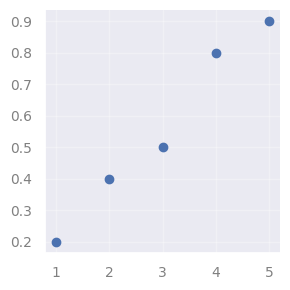

In [2]:
X = [1, 2, 3, 4, 5]
y = [0.2, 0.4, 0.5, 0.8, 0.9]

from matplotlib import pyplot as plt
plt.figure(figsize=(3,3))
plt.scatter(X, y)
plt.show()

... and we want a model that represents the true behavior of the data.

> We may want to use it for:
> - **predicting** new data
> - **explain** the phenomenon that causes our observations

Let's assume a one-dimensional **linear model**, that is, a model of the type:

$$ y = \alpha{}x + \beta $$

where we call $\alpha$ and $\beta$ the model **parameters**.

By changing the parameters we obtain **different models**, e.g.:


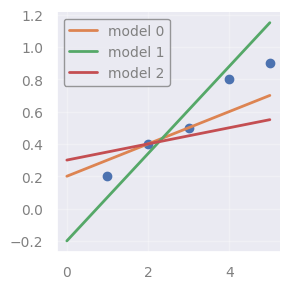

In [3]:
import numpy as np

def funct(xx, alpha, beta):
    return alpha*xx + beta

xx = np.linspace(0 ,5, 100)
'''Notice that `xx` is not the same as `X` (the data), but just
an array of equally spaced values that we use for plotting purposes.'''

alphas = [0.1, 0.27, 0.05]
betas  = [0.2, -0.2, 0.3]

plt.figure(figsize=(3,3))

for i, (alpha, beta) in enumerate(zip(alphas, betas)):

    y_model_i = funct(xx, alpha, beta)
    plt.plot(xx, y_model_i, label='model %s' % i, c=str('C%s' % (i+1)))

plt.scatter(X, y)
plt.legend()
plt.show()

> It is convenient to think that each **parameter set** gives rise to a **different model**<br>
($\rightarrow$ _convenient for when we will talk about "model selection"_)

So the problem of picking the **best-fitting model** becomes $\rightarrow$ _How do I pick the best $\alpha$ and $\beta$?_

**Q:** First of all: what "**best**" means? (_in-class discussion_)

<div class="alert alert-danger alertdanger" role="alert" style="border-radius: 8px; padding: 10px;">
<details>
    
<b><summary>[Spoiler]</summary></b>
    
$\rightarrow$ We need to define a <b>metric of fitness</b>!
   
</details>
</div>

<hr style="height:0.5px; border:none; color:lightgray; background-color:lightgray;">

As a fitness metric, we could use the **error** that each model makes.  For each observed datum, the error is:

$$ err_{i} = y_i - \hat{y}_i$$

where $ \hat{y}_i$ is the model prediction for the corresponding $x_{i}$:


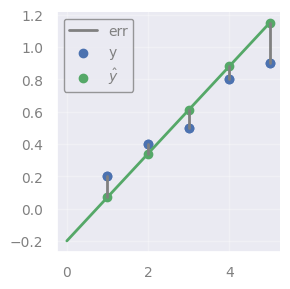

In [4]:
plt.figure(figsize=(3,3))

yhat_1 = funct(np.array(X), alphas[1], betas[1]) # model predictions (dots)
y_model_1 = funct(xx, alphas[1], betas[1]) # just for plotting the model (line)

plt.plot(xx, y_model_1, c='C2')
errs = plt.plot((X, X), (y, yhat_1), c='grey', label='err')
plt.setp(errs[1:], label="_")
plt.scatter(X, y, label='y', c='C0')
plt.scatter(X, yhat_1, label=r'$\hat{y}$', c='C2')

plt.scatter(X, y)
plt.legend()
plt.show()

$\rightarrow$ So what about picking the $\alpha$ and $\beta$ that minimize the errors?

It's easier if we minimize a **single number**, so, we can consider the "sum of errors":

$$ \sum_i err_i = \sum_i (y_i - \hat{y}_i) $$

**Q:** But minimizing this has a problem. Can you guess? (_in-class discussion_)

<div class="alert alert-danger alertdanger" role="alert" style="border-radius: 8px; padding: 10px;">
<details>
    
<b><summary>[Spoiler]</summary></b>
    
$\rightarrow$ The problem here is that positive and negative errors can actually cancel out - resulting in a misleading concluion regarding the performance of the method.   
   
</details>
</div>

<hr style="height:0.5px; border:none; color:lightgray; background-color:lightgray;">

We consider the **sum of squares**:

$$ S = \sum_i err_i^2 = \sum_i (y_i - \hat{y}_i)^2 $$

and hence the **Least Squares Method**:

> The best-fitting parameters (=model) are those that <u>minimize the sum of squares of the errors</u>

<u>IMPORTANT:</u><br>
> The Least Squares method is only <u>one</u> possible optimization method.
>
> As we will see over and over again during this school, there are other **definitions** of "best fitting model" (e.g. _the one that minimizes the absolute error_), as well as countless **algorithms** to find such optimum.

Yet, LS is a very good example to start with, to get the general **intuition** behind optimization.


# Fitting a line via Ordinary Least Squares (OLS)

The linear case offers the _simplest_ application of LS fitting, which goes under the name of **Ordinary Least Squares (OLS)**.

Simple $\rightarrow$ We can solve this <u>analytically</u> (_no approximations, no iterations, computationally fast_).

## Problem definition

_We follow [this wikipedia article on OLS](https://en.wikipedia.org/wiki/Ordinary_least_squares) for the formalism/nomenclature._


We first need to generalize to $p$ dimensions  $\rightarrow$ now, each $X_i$ for sample $i$ is not a single feature (as before), but an **array of features**:

$$X_i = [x_0, x_1, x_2, ..., x_p]~~for~sample~i$$

So, if we have **$n$ samples**, each having **$p$ dimensions**, the data matrix is:

$$ \mathbf{X} = \begin{bmatrix} X_{11} & X_{12} & \cdots & X_{1p} \\ X_{21} & X_{22} & \cdots & X_{2p} \\ \vdots & \vdots & \ddots & \vdots \\ X_{n1} & X_{n2} & \cdots & X_{np} \end{bmatrix} $$


_NOTE: Samples are along rows, in this notation._


<hr style="height:0.5px; border:none; color:lightgray; background-color:lightgray;">

However, the **target variable** is still one-dimensional:

$$ \mathbf{y} = \begin{bmatrix} y_1 \\ y_2 \\ \vdots \\ y_n \end{bmatrix} $$

<hr style="height:0.5px; border:none; color:lightgray; background-color:lightgray;">

Now, for the **model** $-$ In the 1D cases we said it was:

$$ y = \alpha{}x + \beta$$

Generalizing to $p$ dimensions, one could say that the **multi-dimensional model** should be of the form:

$$ y = \beta_1{}x_{1} + \beta_2{}x_{2} + ... + \beta_p{}x_{p} + const$$

... where "_const_" plays the role of $\beta$ in the 1D case, and instead of using $\alpha$, $\beta$, $\gamma$, etc., we just use $\beta_1$, $\beta_2$, $\beta_3$, not to run out of Greek letters!

<hr style="height:0.5px; border:none; color:lightgray; background-color:lightgray;">

We can forget about the const with a small trick, without losing generalization (_again, see [the wikipedia OLS article](https://en.wikipedia.org/wiki/Ordinary_least_squares)_) $-$ so our **generalized multi-dimensional linear model** becomes:

$$ y = \beta_1{}x_{1} + \beta_2{}x_{2} + ... + \beta_p{}x_{p} $$

But, to be formally precise, we should add the index $i$, because this <u>must hold true for _every_ data point $i$</u>:

$$ y_i = \beta_1{}x_{i, 1} + \beta_2{}x_{i, 2} + ... + \beta_p{}x_{i, p} $$

or, in _vector_ notation:

$$ y_i = \pmb{x_{i}}^T \pmb{\beta}$$

for each point $i$.  In _matrix notation_ we can represent the equations for all points in one go:

$$ \pmb{y} = \pmb{X} \pmb{\beta}$$


$$
\mathbf{X} = \begin{bmatrix} X_{11} & X_{12} & \cdots & X_{1p} \\ X_{21} & X_{22} & \cdots & X_{2p} \\ \vdots & \vdots & \ddots & \vdots \\ X_{n1} & X_{n2} & \cdots & X_{np} \end{bmatrix}, \qquad
\boldsymbol{\beta} = \begin{bmatrix} \beta_1 \\ \beta_2 \\ \vdots \\ \beta_p \end{bmatrix}, \qquad
\mathbf{y} = \begin{bmatrix} y_1 \\ y_2 \\ \vdots \\ y_n \end{bmatrix}
$$


<div style="border-left: 4px solid #2196F3; padding-left: 1em; padding-top: 1em; padding-bottom: 1em; margin: 1em 0; background: #f0f8ff; color: #1a1a1a;">

<details>

<b><summary>[Solution] </summary></b>  

_See [this wikipedia article on Least squares](https://en.wikipedia.org/wiki/Least_squares) for the derivation._

The solution is obtained by:

1. **Writing the squares in a convenient form**

$$ S(\pmb{\beta}) = || \pmb{y} - \pmb{X} \pmb{\beta} ||^2$$

$$ = (\pmb{y} - \pmb{X\beta})^T(\pmb{y} - \pmb{X\beta})$$

$$ = \pmb{y}^T\pmb{y} - \pmb{y}^T\pmb{X}\pmb{\beta} - \pmb{\beta}^T\pmb{X}^T\pmb{y} + \pmb{\beta}^T\pmb{X}^T\pmb{X}\pmb{\beta} $$

2. **Finding the minimizer by searching where the derivative of $S(\pmb{\beta})$ equals 0**

$$ 0 = \frac{\partial S(\pmb{\beta})}{\partial \pmb{\beta}} $$

> <u>IMPORTANT</u>: We want to minimize $S(\pmb{\beta})$ with respect to $\pmb{\beta}$, <u>not</u> $\pmb{X}$ !<br>
&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&ensp; $\rightarrow$ _i.e., we are looking for the best parameter set $\hat{\pmb{\beta}}$ that minimizes the squared errors:_
>
> &emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&ensp; $\pmb{\hat{\beta}} = \operatorname{argmin_\beta} S(\pmb{\beta})$

$$ 0 = \frac{\partial S(\pmb{\beta})}{\partial \pmb{\beta}} $$

$$
= \frac{\partial
    ( \pmb{y}^T\pmb{y} - \pmb{y}^T\pmb{X}\pmb{\beta} - \pmb{\beta}^T\pmb{X}^T\pmb{y}
    +\pmb{\beta}^T\pmb{X}^T\pmb{X}\pmb{\beta} )
   }{
    \partial \pmb{\beta}
   }
$$

$$ = -2\pmb{X}^T\pmb{y} + 2\pmb{X}^T\pmb{X}\pmb{\beta} $$

simplifying, and moving terms around it follows:

$$ \pmb{X}^T\pmb{y} =  \pmb{X}^T\pmb{X}\pmb{\beta} $$

   
</details>
</div>

\begin{equation}
    \pmb{\hat{\beta}} = (\pmb{X}^T\pmb{X})^{-1}\pmb{X}^T\pmb{y} \tag{Eq. 1}
\end{equation}

><u>Extremely simple</u>
>
><u>But is it computationally fast?</u><br>  Inverting a matrix (in our case, ($\pmb{X}^T\pmb{X})^{-1}$) is a "heavy lifting" job for a computer.<br>
> $\rightarrow$ _complexity: $\mathcal{O}(n^3)$_



## In python

We will use [`numpy.linalg.lstsq`](https://numpy.org/doc/stable/reference/generated/numpy.linalg.lstsq.html) to fit:

$$ y = \beta_2{}x + \beta_1 $$

to the data seen above (notice that now we call every parameter as "$\beta_{<number>}$", as for the generic multi-dimensional case).


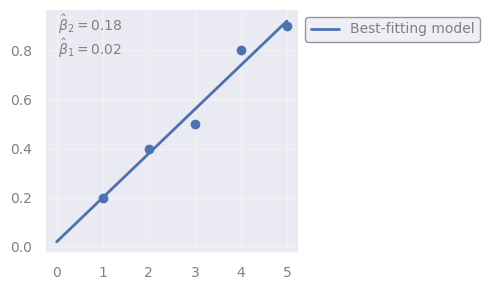

In [5]:
# Same data as above:
X = np.array([1, 2, 3, 4, 5])
y = np.array([0.2, 0.4, 0.5, 0.8, 0.9])

from numpy.linalg import lstsq

X_prime = np.vstack([X, np.ones(len(X))]).T
'''
What is this line doing?! Adding a row of `1`s to our data?! Why?

Remember, above, when we said that we can "hide" the constant in:
    y = beta*X + const
using a trick?

The trick it is to create a "fake", additional feature in X, and fill it
with ones.  This will play the role of the constant.

See the links above, as well as the `np.linalg.lstsq` documentation, here:
    https://numpy.org/doc/stable/reference/generated/numpy.linalg.lstsq.html
''';

beta_2_hat, beta_1_hat = np.linalg.lstsq(X_prime, y, rcond=None)[0]
# best-fitting parameters

fig, ax = plt.subplots(figsize=(5,3), ncols=1, nrows=1)
plt.scatter(X, y)
plt.plot(xx, beta_2_hat*xx + beta_1_hat, 'C0', label='Best-fitting model')
plt.text(.05, .99, '$\\hat{\\beta}_2 = %.2f$' % beta_2_hat, ha='left', va='top', transform=ax.transAxes)
plt.text(.05, .89, '$\\hat{\\beta}_1 = %.2f$' % beta_1_hat, ha='left', va='top', transform=ax.transAxes)
plt.legend(bbox_to_anchor=(1, 1))
plt.show()

## In python - an easier library

Ok, `numpy.linalg.lstsq` is very educational because it solves the OLS problem **algebraically**, just like in Equation 1.<br>
But $-$ as you have seen $-$ it has a clumsy usage.

For practical purposes, we will now on use the much more **intuitive** and **flexible** [`lmfit`](https://lmfit.github.io/lmfit-py/).

> _NOTE: Internally, it uses by default a different algorithm to solve the least-squares problem (see later: "Levenberg-Marquardt"), but we pretend not, for now._


In [9]:
!pip install lmfit --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.7/97.7 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 3.3 MB/s eta 0:00:00


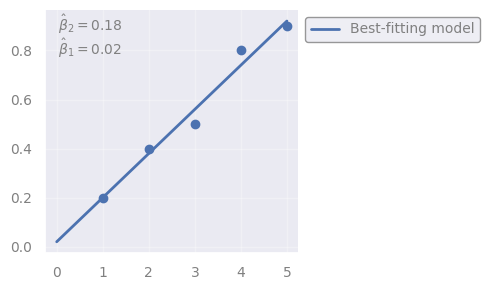

In [10]:
from lmfit import Model

def model_func(x, beta_1, beta_2):
    y = beta_2*x + beta_1
    return y

# Create an lmfit `Model` object:
model = Model(model_func)

# Invoking the `fit()` method, which returns the object `result`:
result = model.fit(y, x=X, beta_1=0, beta_2=1)
'''
Notice that here we are providing some initial guess for `beta_1` and `beta_2`,
this is only because this library is using the Levenberg-Marquardt algorithm.

In reality OLS doesn't need initial guesses when using the algebraic solution,
as demonstrated above by using `np.linalg.lstsq`, which properly solves OLS.

We will see later why Levenberg-Marquardt requires initial guesses.
'''

# Retrieving best-fit parameters:
beta_1_hat = result.params['beta_1'].value
beta_2_hat = result.params['beta_2'].value

xx = np.linspace(0 , np.max(X), 100)
'''Notice that `xx` is not the same as `X` (the data), but just
an array of equally spaced values that we use for plotting purposes.'''

fig, ax = plt.subplots(figsize=(5,3), ncols=1, nrows=1)
plt.scatter(X, y)
plt.plot(xx, beta_2_hat*xx + beta_1_hat, 'C0', label='Best-fitting model')
plt.text(.05, .99, '$\\hat{\\beta}_2 = %.2f$' % beta_2_hat, ha='left', va='top', transform=ax.transAxes)
plt.text(.05, .89, '$\\hat{\\beta}_1 = %.2f$' % beta_1_hat, ha='left', va='top', transform=ax.transAxes)
plt.legend(bbox_to_anchor=(1, 1))
plt.show()

<div style="border-left: 5px solid #FFA500; background-color: rgba(255, 165, 0, 0.15); padding: 10px; border-radius: 4px; color: inherit;">

<font size=4>**Exercise 1 [15 min]**</font>

**Objective:** Evaluate the best-fit model to some data. You will have to assume a model, and then run the Least-Squares minimization on the provided data.

<u>The final goal is to observe what happens when you apply the model to new, "_test_" data.</u>
<br>

**Dataset:** The following one.

**Task:**  In particular, you will have to:
1. Look at the data and assume a model
2. Use only the "_train_" data to perform the LS minimization to find the best model
3. Using the best model, calculate and plot the model predictions on the "_train_" data
4. Calculate and plot the model predictions on the "_test_" data
5. Calculate the squares of errors for the "_train_" ($S_{train}$) and "_test_" ($S_{test}$) data
6. Now compare the two squares of errors $\rightarrow$ _What do you notice?_

**Hints:**
- _For task 5_ $-$ To get the squares of errors you can simply calculate:
$$ S_{train} = \sum_i (y_i - \hat{y}_i)^2 ~~~~~ \forall i \in train$$

$$ S_{test} = \sum_i (y_i - \hat{y}_i)^2 ~~~~~ \forall i \in test$$

&emsp;&ensp; Notice that $-$ once the model has been fit $-$ $S_{train}$ is effectively _the_ minimized Least Squares.<br>
&emsp;&ensp; But what about $ S_{test} $?

</div>

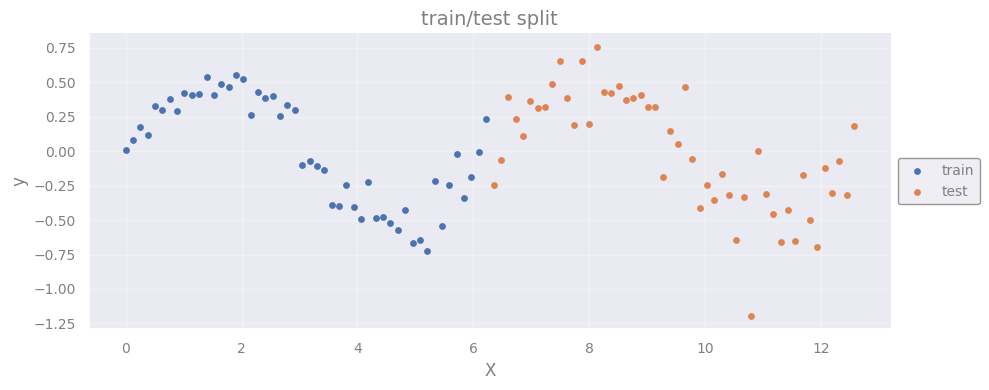

In [11]:
# Loading and plotting data:
import tarfile
import io
from matplotlib import pyplot as plt
import numpy as np

tar = tarfile.open("data/data_inclass_ex1.tar.gz", "r:gz")

def convert_and_load(file):
    with io.BytesIO(file.read()) as f:
        return np.load(f)

for member in tar.getmembers():
    file = tar.extractfile(member)
    if member.name == 'X_train.npy': X_train = convert_and_load(file)
    if member.name == 'y_train.npy': y_train = convert_and_load(file)
    if member.name == 'X_test.npy':  X_test  = convert_and_load(file)
    if member.name == 'y_test.npy':  y_test  = convert_and_load(file)

plt.figure(figsize=(10, 4))
plt.scatter(X_train, y_train, label='train', c='C0', s=15)
plt.scatter(X_test,  y_test,  label='test',  c='C1', s=15)
plt.xlabel('X')
plt.ylabel('y')
plt.title('train/test split')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.show()

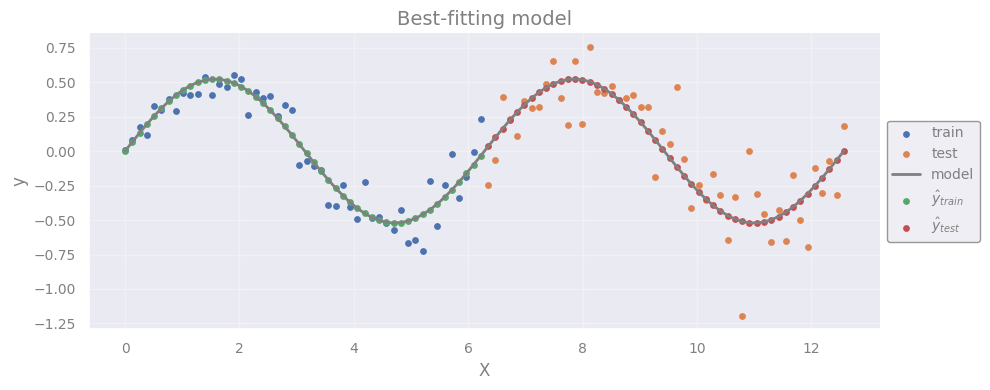

In [20]:
from lmfit import Model

# 1. Assuming a sinusoidal model
#def model_func(x, k, A, phi):
#    y = A*np.sin(k*x + phi)
#    return y

def model_func(x, A):
    y = A*np.sin(x)
    return y

# 2. Using only the "_train_" data to perform the LS minimization

# Create an lmfit `Model` object:
model = Model(model_func)

# Invoking the `fit()` method, which returns the object `result`:
result = model.fit(y_train, x=X_train, A = 0.5)

# Retrieving best-fit parameters:
beta_1_hat = result.params['A'].value

# 3. Calculating and plotting the model predictions on the "_train_" data
# 4. Calculating and plotting the model predictions on the "_test_" data
# Predictions of the model for train/test:
yhat_train = y_train
yhat_test  = y_test

xx = np.linspace(0 ,np.max(X_test), 100)
'''Notice that `xx` is not the same as `X` (the data), but just
an array of equally spaced values that we use for plotting purposes.'''

plt.figure(figsize=(10, 4))
# Data:
plt.scatter(X_train , y_train , label='train', c='C0', s=15)
plt.scatter(X_test , y_test ,  label='test',  c='C1', s=15)
# Model:
plt.plot(xx, model_func(xx, beta_1_hat), label='model', c='grey', lw=2)
# Train predictions:
plt.scatter( X_train , model_func(X_train, beta_1_hat), label=r'$\hat{y}_{train}$', c='C2', s=15)
# Test predictions:
plt.scatter( X_test , model_func(X_test, beta_1_hat) ,  label=r'$\hat{y}_{test}$',  c='C3', s=15)
#
plt.xlabel('X')
plt.ylabel('y')
plt.title('Best-fitting model')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.show()

In [22]:
# 5. Calculating squares of errors for the "_train_" and "_test_":
S_train = np.sum(((model_func(X_train, beta_1_hat))-y_train)**2)
S_test  = np.sum(((model_func(X_test, beta_1_hat))-y_test)**2)

#S_train = np.sum( (yhat_train - y_train)**2 )
#S_test  = np.sum( (yhat_test - y_test)**2 )

# 6. Now comparing the two squares:
print("S_train: %.2f | S_test: %.2f" % (S_train, S_test))

S_train: 0.68 | S_test: 2.43


<div class="alert alert-danger" role="alert" style="border-radius: 8px; padding: 10px;">
    
<b>[Solution at the end !]</b>

</div>

<u>$S_{test}$ is way larger than $S_{train}$</u> $\rightarrow$ **overfitting**

This is to be expected because the model has been trained on $X_{train}$, and, as you can see, $X_{test}$ shows larger variance.

**Q:** What could we do to obtain a more **balanced model** (i.e., a model with similar _performance_ on train and test data)? (_in-class discussion_)


<div style="border-left: 4px solid #e57373; padding-left: 1em; padding-top: 1em; padding-bottom: 1em; margin: 1em 0; background: #fdecea; color: #1a1a1a;">
<details>

<b><summary>[Spoiler]</summary></b>  
    
$\rightarrow$ <b>Shuffle</b> the data!

</details>
</div>

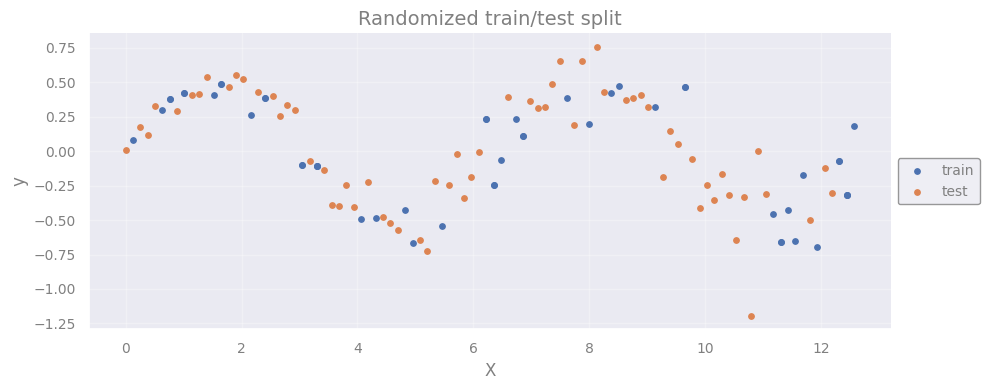

In [23]:
'''Merging train and test data, first.'''
X = np.concatenate((X_train, X_test))
y = np.concatenate((y_train, y_test))

'''
Now performing a random split of the merged data.
Re-running this block will generate a new, randomized split.
'''
idxs_train_ = np.random.choice(np.arange((len(X))), size=len(X_train))
# ^here we pick at random some train indexes from the merged `X`
idxs_test_ = list(set(np.arange((len(X)))) - set(idxs_train_))
# ^here we pick the complementary indexes

X_train_ = X[idxs_train_]
y_train_ = y[idxs_train_]
X_test_ = X[idxs_test_]
y_test_ = y[idxs_test_]

plt.figure(figsize=(10, 4))
plt.scatter(X_train_, y_train_, label='train', c='C0', s=15)
plt.scatter(X_test_,  y_test_,  label='test',  c='C1', s=15)
plt.xlabel('X')
plt.ylabel('y')
plt.title('Randomized train/test split')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.show()

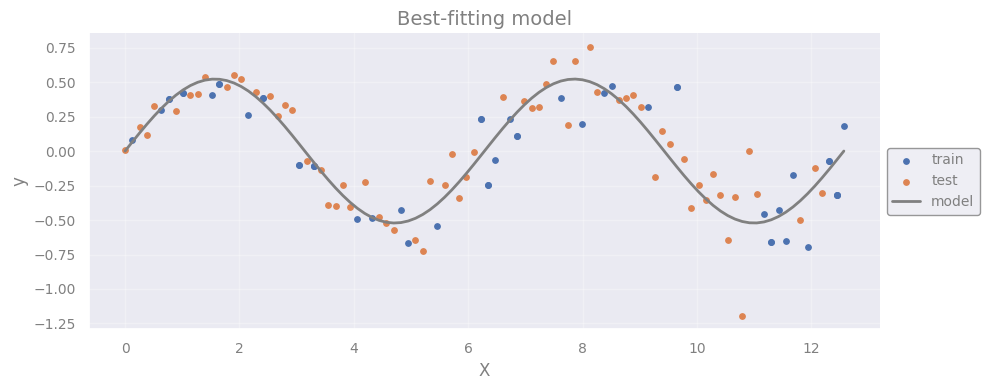

S_train: 1.90 | S_test: 1.90


In [24]:
'''Re-running the same fit as above on the new, randomized split.'''
from lmfit import Model

def model_func(x, beta_1):
    y = beta_1*np.sin(x)
    return y

model = Model(model_func)

result = model.fit(y_train, x=X_train, beta_1=0)

beta_1_hat = result.params['beta_1'].value

yhat_train_ = model_func(X_train_, beta_1_hat)
yhat_test_  = model_func(X_test_,  beta_1_hat)

xx = np.linspace(0 ,np.max(X), 100)

plt.figure(figsize=(10, 4))
plt.scatter(X_train_, y_train_, label='train', c='C0', s=15)
plt.scatter(X_test_,  y_test_,  label='test',  c='C1', s=15)
plt.plot(xx, model_func(xx, beta_1_hat), label='model', c='grey', lw=2)
#
plt.xlabel('X')
plt.ylabel('y')
plt.title('Best-fitting model')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.show()

S_train = np.sum( (yhat_train_ - y_train_)**2 )
S_test  = np.sum( (yhat_test_ - y_test_)**2 )
print("S_train: %.2f | S_test: %.2f" % (S_train, S_test))

# Non-linear least squares: Levenberg-Marquardt algorithm

We saw **linear** problems, i.e. when the model is **linear in the parameters**, e.g.:

$$ y = \beta_2 x + \beta_1 ~~~~~or~~~~~ y = \beta_1 sin(x) $$

What about the **non-linear** problems, i.e. when the model is **<u>not</u> linear in the parameters**, e.g.:

$$ y = \beta_1e^{\beta_2 x} ~~~~~or~~~~~ y = sin(\beta_1 x) ~~~~?$$

In general, LS not solvable algebraically $\rightarrow$ Need to <u>converge to the solution</u>!

## Brute-force approach (spoiler: doesn't work!)

> <u>Objective:</u> The taks is $-$ as usual $-$ to find the parameter set $\hat{\pmb{\beta}}$ that **minimizes the sum of squares** $S(\pmb{\beta})$.

So, let's say that we have a model of the type:

$$ y = \beta_1e^{\beta_2 x} $$

and we want to find $\hat{\pmb{\beta}} = (\hat{\beta_1}, \hat{\beta_2})$ that minimizes $S(\beta_1, \beta_2)$.

<hr style="height:0.5px; border:none; color:lightgray; background-color:lightgray;">

Let's **assume** we could potentially explore _all possible_ parameter combinations.

For each given $(\bar{\beta}_1, \bar{\beta_2})$ set, we:
- Create a the corresponding model: $\bar{y}_{pred} = \bar{\beta}_1e^{\bar{\beta}_2 x} $
- Calculate $S(\bar{\beta}_1, \bar{\beta}_2) = \sum_i^{n}(\bar{y}_{i, pred} - y_{i, obs})^2$

... and repeat _ad infinitum_.

$\rightarrow$ Then, we could hypothetically map the _whole_ $S(\beta_1, \beta_2)$ space:

<img src="https://github.com/AstroStat-Academy/astrostat-school-8/blob/main/Optimization/images/S.png?raw=1" width=600 style="display:block; margin-left:auto; margin-right:auto;">

> Except that this <u>will take forever</u>!


## Iterative approach (now we are talking!)

Instead, we may want to **converge** to the best solution $\hat{\pmb{\beta}} = (\hat{\beta_1}, \hat{\beta_2})$.<br>
(_possibly in a fast way_)

> We will accept a compromise: **approximate solution**.

1. We start from a **blank state**:

<img src="https://github.com/AstroStat-Academy/astrostat-school-8/blob/main/Optimization/images/S_blank.png?raw=1" width=600 style="display:block; margin-left:auto; margin-right:auto;">



2. Or, better, from an **initial guess** $(\beta^A_1, \beta^A_2)$:<br>
(_We look at the function, we had an enlightment, we used cheat codes, etc._)

<img src="https://github.com/AstroStat-Academy/astrostat-school-8/blob/main/Optimization/images/LM_1st_guess.png?raw=1" width=600 style="display:block; margin-left:auto; margin-right:auto;">


_NOTE: Here we conveniently show the neighborhood around the point we pick._


**Q:** Where to take the <u>next guess</u>?


<div style="border-left: 4px solid #e57373; padding-left: 1em; padding-top: 1em; padding-bottom: 1em; margin: 1em 0; background: #fdecea; color: #1a1a1a;">
<details>

<b><summary>[Spoiler]</summary></b>  

   
What about looking at the <b>gradient</b> (i.e., <b>derivative</b>) around that point $\rightarrow$ it points towards where the $S(\beta_1, \beta_2)$ is decreasing.
    
<table><tr>
    <td width=600>
        <img src="https://github.com/AstroStat-Academy/astrostat-school-8/blob/main/Optimization/images/LM_1st_gradient.png?raw=1">
    </td>
</tr></table>

Let's follow the white rabbit and see where it leads us ...

</details>
</div>

3. We take the **next guess**  $(\beta^B_1, \beta^B_2)$ _somewhere along the gradient_:

<img src="https://github.com/AstroStat-Academy/astrostat-school-8/blob/main/Optimization/images/LM_2nd_guess.png?raw=1" width=600 style="display:block; margin-left:auto; margin-right:auto;">


> Not bad! It lead us to a lower $S(\beta_1, \beta_2)$.  Let's try again ...


4. We take **another guess** _somewhere along the gradient_:

<img src="https://github.com/AstroStat-Academy/astrostat-school-8/blob/main/Optimization/images/LM_3rd_guess.png?raw=1" width=600 style="display:block; margin-left:auto; margin-right:auto;">


5. And again, and again .. **until we are happy** (_define happy_)

<img src="https://github.com/AstroStat-Academy/astrostat-school-8/blob/main/Optimization/images/LM_4th_guess.png?raw=1" width=600 style="display:block; margin-left:auto; margin-right:auto;">


## The mathematical approach


_NOTE: The theory in this section is adopted from this [wikipedia article on Levenberg-Marquardt algorithm](https://en.wikipedia.org/wiki/Levenberg%E2%80%93Marquardt_algorithm)_

<hr style="height:0.5px; border:none; color:lightgray; background-color:lightgray;">

Let's call: $\hat{y}_i := f(x_i, \pmb{\beta})$ $\leftarrow$ model value for $x_i$

- The initial guess for the best-fit parameters is $\pmb{\bar{\beta}}$.

- The next guess is: $\pmb{\bar{\beta}}^{\prime} \leftarrow \pmb{\bar{\beta}} + \pmb{\delta}$, where $\pmb{\delta}$ is the small amount we move by.

<u>**Objective:**</u> Update $\pmb{\bar{\beta}}$ until we minimized $S(\pmb{\beta})$


<div style="border-left: 4px solid #2196F3; padding-left: 1em; padding-top: 1em; padding-bottom: 1em; margin: 1em 0; background: #f0f8ff; color: #1a1a1a;">

<details>

<b><summary>[The math details]</summary></b>
    
We can use the Taylor expansion to approximate $f(x_i, \pmb{\bar{\beta}}^{\prime})$ around $\pmb{\bar{\beta}}$:

$$ f(x_i, \pmb{\bar{\beta}} + \pmb{\delta}) \approx f(x_i, \pmb{\bar{\beta}}) + {\partial f(x_i, \pmb{\beta}) \over \partial\pmb{\beta}} \pmb{\delta} $$

<u>IMPORTANT:</u> Notice that **the derivative is on the parameters** ($\pmb{\beta}$), <u>not</u> the data ($x_i$) ! $\rightarrow$ We want to explore the _neighborhood_ of $\pmb{\bar{\beta}}$ !

We can define $\pmb{J_i} := {\partial f(x_i, \pmb{\beta}) \over \partial\pmb{\beta}} $, so:

$$
\begin{equation}
 f(x_i, \pmb{\bar{\beta}} + \pmb{\delta}) \approx f(x_i, \pmb{\bar{\beta}}) + \pmb{J_i}\pmb{\delta}  \tag{Eq. 2}
\end{equation}
$$

<u>**Algorithm:**</u>

We now need to define how much to move, to find the next guess $\rightarrow$ $\pmb{\delta} = ?$

We will find it by solving the usual problem $\rightarrow$ **minimize the sum of squares**.

If the next guess $\pmb{\bar{\beta}} + \pmb{\delta}$ corresponds to a true minimum, then $S(\pmb{\bar{\beta}} + \pmb{\delta})$ must have derivative = 0 (w/r to vector $\pmb{\delta}$):

$$ {\partial S(\pmb{\bar{\beta}} + \pmb{\delta}) \over \partial\pmb{\delta}} = 0 $$

> _Meaning: moving away from $\pmb{\bar{\beta}} + \pmb{\delta}$ causes a worst result._

Let's solve it, starting from the approximation of _Equation 2_:

$
\begin{align}
 S(\pmb{\bar{\beta}} + \pmb{\delta}) = & \sum_{i}^n [y_i - f(x_i, \pmb{\bar{\beta}} + \pmb{\delta})]^2\\
 \approx & \sum_{i}^n [y_i - f(x_i, \pmb{\bar{\beta}}) - \pmb{J_i}\pmb{\delta}]^2\\
\end{align}
$

Which $-$ in vector notation $-$ becomes:

$
\begin{align}
 S(\pmb{\bar{\beta}} + \pmb{\delta}) \approx & ~||\pmb{y} - \pmb{f(\bar{\beta})} - \pmb{J}\pmb{\delta}||^2\\
 = & ~[\pmb{y} - \pmb{f(\bar{\beta})} - \pmb{J}\pmb{\delta}]^T[\pmb{y} - \pmb{f(\bar{\beta})} - \pmb{J}\pmb{\delta}]\\
 = & ~[\pmb{y} - \pmb{f(\bar{\beta})}]^T[\pmb{y} - \pmb{f(\bar{\beta})}] - [\pmb{y} - \pmb{f(\bar{\beta})}]^T\pmb{J}\pmb{\delta} - (\pmb{J}\pmb{\delta})^T[\pmb{y} - \pmb{f(\bar{\beta})}] + \pmb{\delta}^T\pmb{J}^T\pmb{J}\pmb{\delta}\\
 = & ~[\pmb{y} - \pmb{f(\bar{\beta})}]^T[\pmb{y} - \pmb{f(\bar{\beta})}] - 2[\pmb{y} - \pmb{f(\bar{\beta})}]^T\pmb{J}\pmb{\delta} + \pmb{\delta}^T\pmb{J}^T\pmb{J}\pmb{\delta}\\
\end{align}
$

Now we take the derivative w/r to vector $\pmb{\delta}$ ([_this tables will help to follow the calculations_](https://en.wikipedia.org/wiki/Matrix_calculus)):

$
\begin{align}
0 = & ~{\partial S(\pmb{\bar{\beta}} + \pmb{\delta}) \over \partial\pmb{\delta}}\\
= &~ -2\pmb{J}^T[\pmb{y} - \pmb{f(\bar{\beta})}] + 2\pmb{J}^T\pmb{J}\pmb{\delta}\\
= &~ -\pmb{J}^T[\pmb{y} - \pmb{f(\bar{\beta})}] + \pmb{J}^T\pmb{J}\pmb{\delta}\\
\end{align}
$

.. which, re-arranging, gives:

</details>
</div>

$$
\begin{equation}
 \pmb{\delta} = \left( \pmb{J}^T \pmb{J} \right)^{-1} \pmb{J}^T \left[\pmb{y} - \pmb{f}(\bar{\pmb{\beta}})\right] \tag{Eq. 3}
\end{equation}
$$

$\rightarrow$ set of $p$ linear equations ($p$ = number of parameters) that **can be solved for** $\pmb{\delta}$ !

> To get to a better minimum, we can just **repeat the procedure** by replacing the starting point: $\pmb{\bar{\beta}}^{\prime} = \pmb{\bar{\beta}} + \pmb{\delta}$, move to $\pmb{\bar{\beta}}^{\prime} + \pmb{\delta}^{\prime}$, etc. <br>
> ... until we are happy.


## Actual Levenberg & Marquardt algorithm

- Equation 3 (see math above) is known as **Gauss-Newton** method (1700-1800 _ca._)

- The **Levenberg** modification (1944) is:

$$
\begin{equation}
 \pmb{\delta} = \left( \pmb{J}^T \pmb{J} + \lambda \pmb{I} \right)^{-1} \pmb{J}^T \left[ \pmb{y} - \pmb{f}(\bar{\pmb{\beta}}) \right]
\end{equation}
$$

$\lambda$ $\rightarrow$ damping factor

> Helps for **faster convergence** and **larger accuracy** in finding the minimum

Adjusted at each iteration:
- if $S(\pmb{\beta})$ decreases rapidly $\rightarrow$ $\lambda$ is decreased (_deceleration_)
- if $S(\pmb{\beta})$ doesn't decrease enough $\rightarrow$ $\lambda$ is increased (_push_)

<div style="border-left: 4px solid #4CAF50; padding-left: 1em; padding-top: 1em; padding-bottom: 1em; margin: 1em 0; background: #e8f5e9; color: #1a1a1a;">
    
**NOTE:** This approach does not guranteed a global minimum. Depending on the initial choice of parameters we may end up in different local minima.

</div>


## Further reads

- **Marquardt** contribution $\rightarrow$ [wikipedia article on Levenberg-Marquardt algorithm](https://en.wikipedia.org/wiki/Levenberg%E2%80%93Marquardt_algorithm)
- **Stopping** criteria $\rightarrow$ [wikipedia article on Levenberg-Marquardt algorithm](https://en.wikipedia.org/wiki/Levenberg%E2%80%93Marquardt_algorithm)
- **Shortcomings** of L-M $\rightarrow$ [this blog](https://python4mpia.github.io/fitting_data/least-squares-fitting.html)

<div style="border-left: 5px solid #FFA500; background-color: rgba(255, 165, 0, 0.15); padding: 10px; border-radius: 4px; color: inherit;">

<font size=4>**Exercise 2 [20 min] - Fitting the SN 1987A light curve**</font>

After the explosion of a core-collapse supernova, the optical light curve is powered by the radioactive decay chain:

$${}^{56}\text{Ni} \xrightarrow{\tau = 8.8\,\text{d}} {}^{56}\text{Co} \xrightarrow{\tau = 111.5\,\text{d}} {}^{56}\text{Fe}$$

The $^{56}$Ni decays quickly (half-life ~6 days), so from $t \gtrsim 130$ days the light curve is dominated entirely by $^{56}$Co decay, following a <b>pure exponential</b>:

$$L(t) = L_0 \, e^{-t / \tau_{\rm Co}}$$

where $L_0$ is the luminosity extrapolated to $t=0$ (encodes the $^{56}$Ni mass synthesized in the explosion) and $\tau_{\rm Co} = 111.5$ days is the mean lifetime of $^{56}$Co.

Why is this non-linear? $\tau_{\rm Co}$ appears <b>in the exponent</b>, and that is why we need an iterative method like Levenberg-Marquardt.


**Objective:** Evaluate the best-fit model to the data. But you should be careful where the fit is valid.
    
**Dataset:** The UVOIR bolometric light curve of SN 1987A from [Suntzeff & Bouchet (1990, AJ 99, 650)](https://ui.adsabs.harvard.edu/abs/1990AJ.....99..650S), Table II — the closest supernova observed in modern times (~50 kpc, Large Magellanic Cloud). 161 measurements from day 1 to day 903 since the explosion.


**Tasks:**  In particular, you will have to:
1. Look at the data and define where the fit should be applied.
2. Define the model function
3. Provide physically motivated initial guesses for `L0` and `tau` — use the log-scale plot to estimate them by eye _(hint: in log scale the model is a straight line with slope     $-1/(\tau \cdot \ln 10)$; `L0` is the $t=0$ extrapolation)_
4. Run the fit on the appropriate fitted range only
5. Plot the data and best-fit model together (log scale recommended)
. Compare your recovered $\hat{\tau}$ against the known value $\tau_{\rm Co} = 111.5$ days — do they agree within the fit uncertainties?
6. **Extension:** Using your best-fit $L_0$, convert it to a $^{56}$Ni mass using:

$$M(^{56}\text{Ni}) = \frac{L_0}{\lambda_{\rm Co} \cdot \epsilon_{\rm Co} \cdot N_A / A}$$

where $\lambda_{\rm Co} = 1/(\tau_{\rm Co} \cdot 86400)$ s$^{-1}$, $\epsilon_{\rm Co} = 3.85$ MeV $= 6.17 \times 10^{-6}$ erg per decay, $N_A = 6.022\times10^{23}$ mol$^{-1}$, $A=56$ g/mol. Express in solar masses and compare with Seitenzahl et al. (2014): $M(^{56}\text{Ni}) = 0.071 \pm 0.003\,M_\odot$.
    
</div>

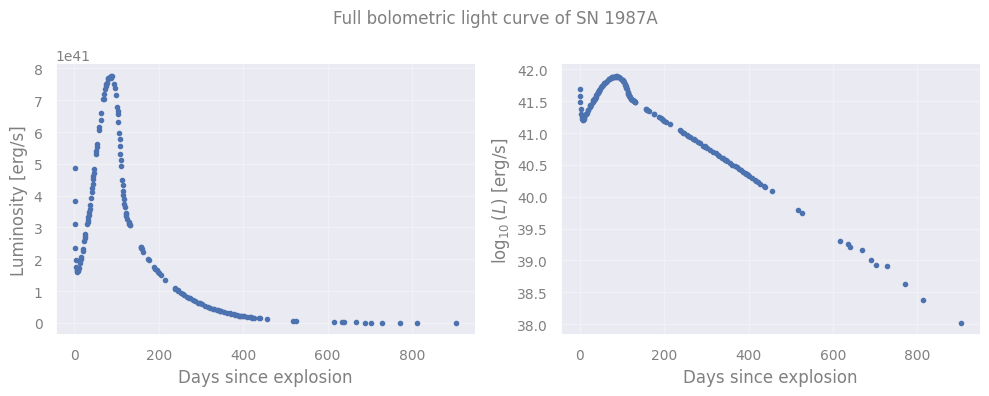

In [27]:
import numpy as np
import matplotlib.pyplot as plt

data = np.loadtxt('data/SN1987A_Suntzeff1990_TableII.txt', comments='#')

time = data[:,0]
logL = data[:,1]
Lum = 10**(logL)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# plot luminosity here
axes[0].plot(time , Lum , 'o', ms=3, c='C0')
axes[0].set_xlabel('Days since explosion')
axes[0].set_ylabel('Luminosity [erg/s]')

# plot logL here - to showcase linearity in log space
axes[1].plot(time , logL , 'o', ms=3, c='C0')
axes[1].set_xlabel('Days since explosion')
axes[1].set_ylabel(r'$\log_{10}(L)$ [erg/s]')

plt.suptitle('Full bolometric light curve of SN 1987A')
plt.tight_layout()
plt.show()


In [28]:
lum_max_idx = np.argmax(Lum)
time_at_max = time[lum_max_idx]
time_at_max

np.float64(86.65)

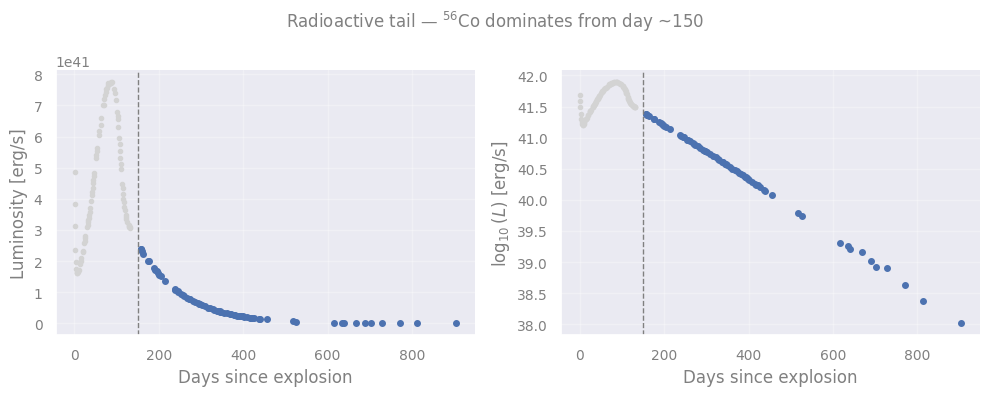

In [32]:
# Select the radioactive tail (after that many days)
#mask = (time >= time_at_max)
mask = (time >= 150)

time_tail = time[mask]
logL_tail = logL[mask]
Lum_tail = Lum[mask]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].plot(time[~mask], Lum[~mask], 'o', ms=3, c='lightgrey', label='Early phase (excluded)')
axes[0].plot(time_tail, Lum_tail, 'o', ms=4, c='C0', label='Radioactive tail (fit region)')
axes[0].axvline(150, ls='--', c='grey', lw=1, label='Day 150 (fit start)')
axes[0].set_xlabel('Days since explosion')
axes[0].set_ylabel('Luminosity [erg/s]')


axes[1].plot(time[~mask], logL[~mask], 'o', ms=3, c='lightgrey', label='Early phase (excluded)')
axes[1].plot(time_tail, logL_tail, 'o', ms=4, c='C0', label='Radioactive tail (fit region)')
axes[1].axvline(150, ls='--', c='grey', lw=1, label='Day 150 (fit start)')
axes[1].set_xlabel('Days since explosion')
axes[1].set_ylabel(r'$\log_{10}(L)$ [erg/s]')

plt.suptitle('Radioactive tail — $^{56}$Co dominates from day ~150')
plt.tight_layout()
plt.show()


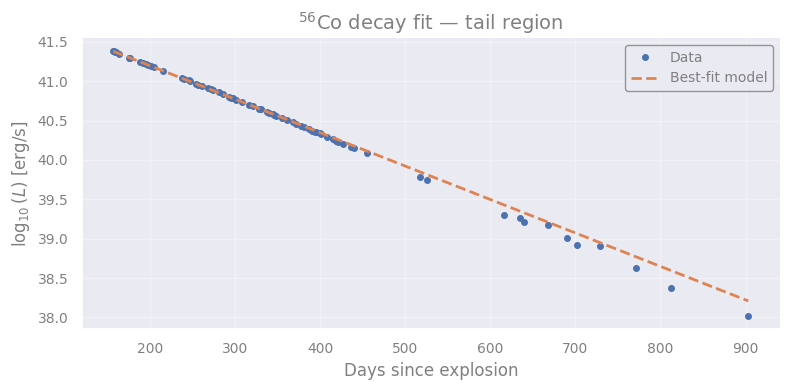


--- Parameter comparison ---
Recovered  tau = 102.19 ± 0.18 days
Known  tau_Co  = 111.5 days
Difference     = 9.11 days  (50.5 sigma)


In [35]:
from lmfit import Model

# 1. Model function
def decay_model( t, L0, tau ):
    return L0*np.exp(-t/tau)

# 2. Initial guesses from the log-scale plot:

L0_guess  = 10**42
tau_guess = 200

model  = Model(decay_model)
result = model.fit(Lum_tail, t=time_tail, L0=L0_guess, tau=tau_guess)

# 4. Plot
# data for model
tt = np.linspace(time_tail[0], time_tail[-1], 1000)
logL_tt = np.log10(result.eval(t=tt))

plt.plot( time_tail , logL_tail, 'o', ms=4, c='C0', label='Data')
plt.plot(tt , logL_tt, lw=2, c='C1', ls='--', label='Best-fit model')
plt.xlabel('Days since explosion')
plt.ylabel(r'$\log_{10}(L)$ [erg/s]')
plt.title(r'$^{56}$Co decay fit — tail region')
plt.legend()

plt.show()

# 5. Parameter comparison
L0_fit  = result.params['L0'].value
L0_err  = result.params['L0'].stderr
tau_fit = result.params['tau'].value
tau_err = result.params['tau'].stderr

print(f"\n--- Parameter comparison ---")
print(f"Recovered  tau = {tau_fit:.2f} ± {tau_err:.2f} days")
print(f"Known  tau_Co  = 111.5 days")
print(f"Difference     = {abs(tau_fit - 111.3):.2f} days  ({abs(tau_fit - 111.3)/tau_err:.1f} sigma)")

<div class="alert alert-danger" role="alert" style="border-radius: 8px; padding: 10px;">

<b>[Solution at the end!]</b>

</div>

# Chi-square (χ$^{2}$) fitting

> Basically, it's **least squares for when data have uncertainties on y**


Instead of minimizing the sum of squares $S(\pmb{\beta})$, we minimize the **weighted average of the sum of squares**, i.e., $\chi^2$:

$$
\chi^2 = \sum_i {(y_i - \hat{y_i})^2 \over \sigma_i^2}
$$

... where the weigths are the **measurement uncertainties** $\sigma_i$.

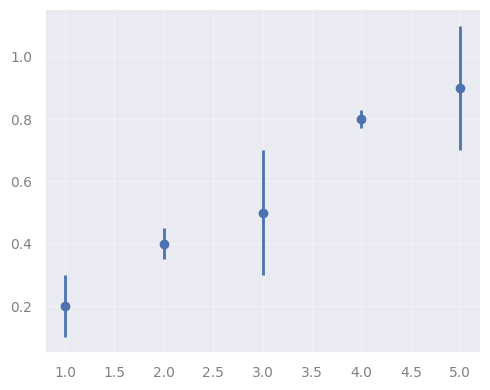

In [37]:
x = np.array([1, 2, 3, 4, 5])
y = np.array([0.2, 0.4, 0.5, 0.8, 0.9])
y_err = np.array([0.1, 0.05, 0.2, 0.03, 0.2])

plt.figure(figsize=(5,4))
plt.errorbar(x, y, yerr=y_err, marker="o", ls="none")
plt.show()

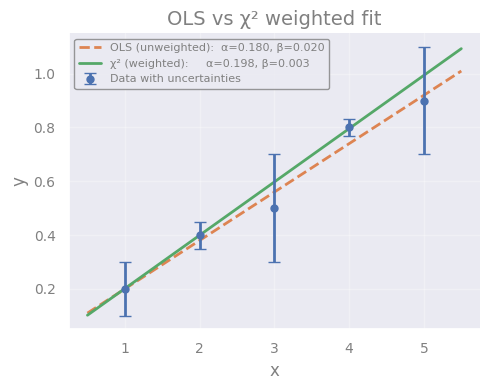

Point weights (1/sigma):
  x=0.0, y=0.2, σ=0.10  →  weight=10.0
  x=0.12693303650867852, y=0.4, σ=0.05  →  weight=20.0
  x=0.25386607301735703, y=0.5, σ=0.20  →  weight=5.0
  x=0.3807991095260356, y=0.8, σ=0.03  →  weight=33.3
  x=0.5077321460347141, y=0.9, σ=0.20  →  weight=5.0


In [41]:
def linear(x, alpha, beta):
    return alpha * x + beta

model = Model(linear)

# Unweighted fit (OLS)
result_ols = model.fit(y, x=x, alpha=0.1, beta=0.1)

# Weighted fit (chi-square) — weights = 1/sigma
result_chi2 = model.fit(y, x=x, weights=1/y_err, alpha=0.1, beta=0.1)
'''
lmfit supports chi2 fitting directly via the "weights" argument. In this case we put 1/sigma_i
as the weight for each point, so that points with small errors count more and
points with large errors count less.
'''

xx = np.linspace(0.5, 5.5, 200)

plt.figure(figsize=(5, 4))
plt.errorbar(x, y, yerr=y_err, fmt='o', ms=5, capsize=4,
             color='C0', label='Data with uncertainties', zorder=3)
plt.plot(xx, result_ols.eval(x=xx),  lw=2, ls='--', color='C1',
         label=f'OLS (unweighted):  α={result_ols.params["alpha"].value:.3f}, '
               f'β={result_ols.params["beta"].value:.3f}')
plt.plot(xx, result_chi2.eval(x=xx), lw=2, color='C2',
         label=f'χ² (weighted):     α={result_chi2.params["alpha"].value:.3f}, '
               f'β={result_chi2.params["beta"].value:.3f}')
plt.xlabel('x')
plt.ylabel('y')
plt.title('OLS vs χ² weighted fit')
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

# Show which points drive the chi2 fit
print("Point weights (1/sigma):")
for xi, yi, si in zip(X, y, y_err):
    print(f"  x={xi}, y={yi}, σ={si:.2f}  →  weight={1/si:.1f}")

Notice how the two fits differ:

- Point at $x=2$ has $\sigma=0.05$ → weight **20** → pulls the χ² fit strongly
- Point at $x=3$ has $\sigma=0.20$ → weight **5**  → nearly ignored by χ² fit
- Point at $x=4$ has $\sigma=0.03$ → weight **33** → dominates the χ² fit

The χ² fit passes closer to the most **precisely measured** points,
which is the physically correct behaviour — a measurement with a small
uncertainty is more trustworthy and should constrain the model more.

> **When to use χ²:** whenever your data points have known, unequal uncertainties —
> which is almost always the case in astronomy.


## Further reads

- Why do we use the "**reduced**" $\chi^2$ to compare model results (i.e., $\chi_{\nu}^2$) ? $\rightarrow$ [Andrae et al. 2010](https://arxiv.org/pdf/1012.3754.pdf)



# Stochastic Gradient Descent - teaser

> **Gradient descent** is just one of the alternatives to L-M to **minimize $S(\pmb{\beta})$**

The update of the parameters goes as:

$$
\begin{equation}
 \pmb{\beta}^\prime \leftarrow \pmb{\beta} - \eta \nabla S(\pmb{\beta}) \tag{Eq. 5}
\end{equation}
$$

where $\nabla$ is the gradient of $S(\pmb{\beta})$.

> Meaning: **descend** along the **gradient** by a multiplicative factor $\eta$

For comparison $\rightarrow$ In Levenberg's algorithm (_Equation 4_), the factor $\lambda$ was additive.

<hr style="height:0.5px; border:none; color:lightgray; background-color:lightgray;">

The gradient becomes **stochastic** when the update of Equation 5 is done **sample by sample**:

<img src="https://github.com/AstroStat-Academy/astrostat-school-8/blob/main/Optimization/images/SGD.png?raw=1" width=600 style="display:block; margin-left:auto; margin-right:auto;">

<table><tr>
    <td width=600>
        <center>
            <br>
            Stochastic Gradient Descent in action.<br>
            (From Figure 4-9 in <a href="https://github.com/ageron/handson-ml2">Gerone, A. "<i>Hands-on Machine Learning with Scikit-Learn, Keras and TensorFlow</i>"</a>)
        </center>
    </td>
</tr></table>

$\rightarrow$ _More on Gradient Descent in the Deep Learning Introduction!_


# Optimization is everywhere!

In the next lectures you will see:

- **MLE**: Maximum Likelihood Estimation
- **MCMC**: Markov Chain Monte Carlo
- **Deep Learning**: Neural Network Optimization
- **SBI**: Simulation Based Inference

... keep your mind open $-$ you can interpret them as <u>different flavors</u> of **optimization**!


# Solutions to the exercises

## Exercise 1

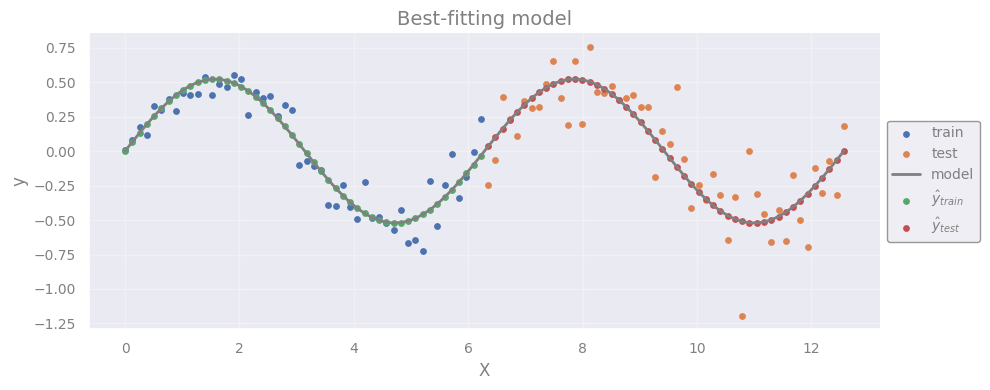

In [ ]:
from lmfit import Model

# 1. Assuming a sinusoidal model
def model_func(x, beta_1):
    y = beta_1*np.sin(x)
    return y

# 2. Using only the "_train_" data to perform the LS minimization

# Create an lmfit `Model` object:
model = Model(model_func)

# Invoking the `fit()` method, which returns the object `result`:
result = model.fit(y_train, x=X_train, beta_1=0)

# Retrieving best-fit parameters:
beta_1_hat = result.params['beta_1'].value

# 3. Calculating and plotting the model predictions on the "_train_" data
# 4. Calculating and plotting the model predictions on the "_test_" data
# Predictions of the model for train/test:
yhat_train = model_func(X_train, beta_1_hat)
yhat_test  = model_func(X_test,  beta_1_hat)

xx = np.linspace(0 ,np.max(X_test), 100)
'''Notice that `xx` is not the same as `X` (the data), but just
an array of equally spaced values that we use for plotting purposes.'''

plt.figure(figsize=(10, 4))
# Data:
plt.scatter(X_train, y_train, label='train', c='C0', s=15)
plt.scatter(X_test,  y_test,  label='test',  c='C1', s=15)
# Model:
plt.plot(xx, model_func(xx, beta_1_hat), label='model', c='grey', lw=2)
# Train predictions:
plt.scatter(X_train, yhat_train, label=r'$\hat{y}_{train}$', c='C2', s=15)
# Test predictions:
plt.scatter(X_test,  yhat_test,  label=r'$\hat{y}_{test}$',  c='C3', s=15)
#
plt.xlabel('X')
plt.ylabel('y')
plt.title('Best-fitting model')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.show()

In [ ]:
# 5. Calculating squares of errors for the "_train_" and "_test_":
S_train = np.sum( (yhat_train - y_train)**2 )
S_test  = np.sum( (yhat_test - y_test)**2 )

# 6. Now comparing the two squares:
print("S_train: %.2f | S_test: %.2f" % (S_train, S_test))

S_train: 0.68 | S_test: 2.43


## Exercise 2

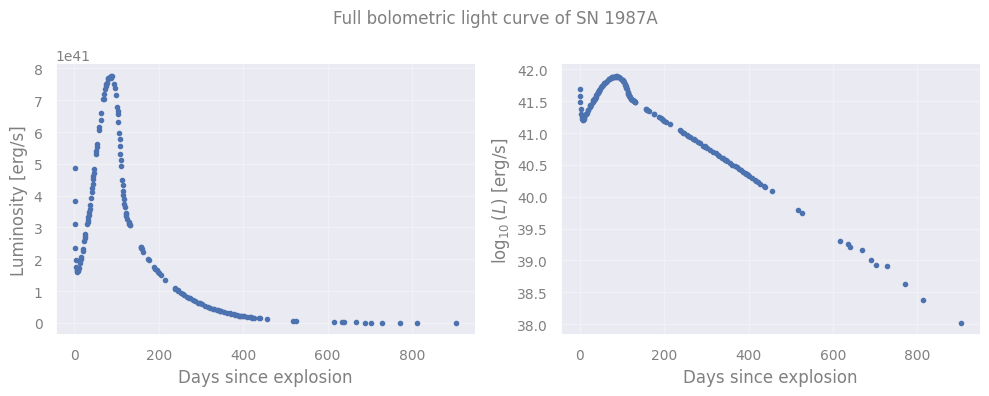

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

data = np.loadtxt('data/SN1987A_Suntzeff1990_TableII.txt', comments='#')

time = data[:,0]
logL = data[:,1]
Lum = 10**logL

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].plot(time, Lum, 'o', ms=3, c='C0')
axes[0].set_xlabel('Days since explosion')
axes[0].set_ylabel('Luminosity [erg/s]')

axes[1].plot(time, logL, 'o', ms=3, c='C0')
axes[1].set_xlabel('Days since explosion')
axes[1].set_ylabel(r'$\log_{10}(L)$ [erg/s]')

plt.suptitle('Full bolometric light curve of SN 1987A')
plt.tight_layout()
plt.show()


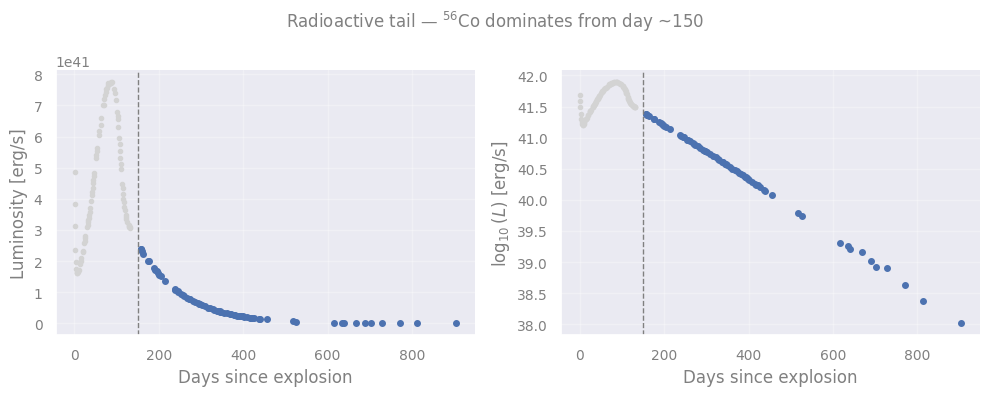

In [ ]:
# Select the radioactive tail: t >= 150 days
mask = (time >= 150)        #& (time<=400)
time_tail = time[mask]
logL_tail = logL[mask]
Lum_tail = Lum[mask]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].plot(time[~mask], Lum[~mask], 'o', ms=3, c='lightgrey', label='Early phase (excluded)')
axes[0].plot(time_tail, Lum_tail, 'o', ms=4, c='C0', label='Radioactive tail (fit region)')
axes[0].axvline(150, ls='--', c='grey', lw=1, label='Day 150 (fit start)')
axes[0].set_xlabel('Days since explosion')
axes[0].set_ylabel('Luminosity [erg/s]')


axes[1].plot(time[~mask], logL[~mask], 'o', ms=3, c='lightgrey', label='Early phase (excluded)')
axes[1].plot(time_tail, logL_tail, 'o', ms=4, c='C0', label='Radioactive tail (fit region)')
axes[1].axvline(150, ls='--', c='grey', lw=1, label='Day 150 (fit start)')
axes[1].set_xlabel('Days since explosion')
axes[1].set_ylabel(r'$\log_{10}(L)$ [erg/s]')

plt.suptitle('Radioactive tail — $^{56}$Co dominates from day ~150')
plt.tight_layout()
plt.show()


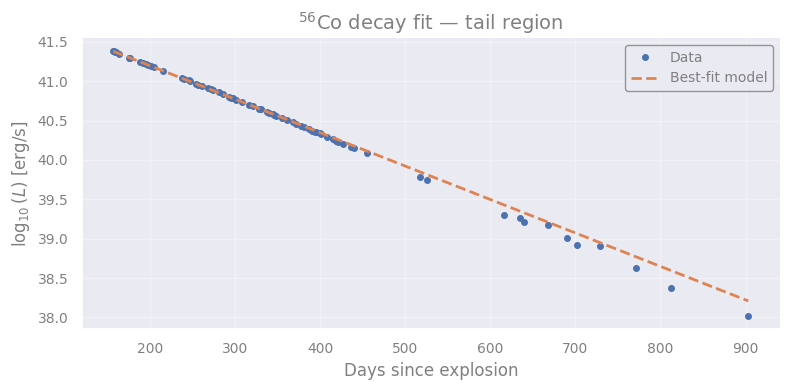


--- Parameter comparison ---
Recovered  tau = 102.19 ± 0.18 days
Known  tau_Co  = 111.30 days
Difference     = 9.11 days  (51.6 sigma)


In [ ]:
from lmfit import Model

# 1. Model function
def decay_model(t, L0, tau):
    return L0 * np.exp(-t / tau)

# 2. Initial guesses from the log-scale plot:

#    In log scale the tail is a straight line: log10(L) = log10(L0) - t/(tau*ln10)
#    Reading off the plot: at t=200, log10(L)~41.2; at t=600, log10(L)~39.7
#    slope = (39.7 - 41.2) / (600 - 200) = -0.00375
#    => tau ~ 1 / (0.00375 * ln10) ~ 116 days  — reasonable initial guess
#    Extrapolating to t=0: intercept ~ 41.2 + 200*0.00375 = 41.95 => L0 ~ 10^41.95

L0_guess  = 10**42.0
tau_guess = 116    # days — deliberately imprecise to show LM convergence

model  = Model(decay_model)
result = model.fit(Lum_tail, t=time_tail, L0=L0_guess, tau=tau_guess)

#print(result.fit_report())

# 4. Plot
tt = np.linspace(time_tail[0], time_tail[-1], 1000)

logL_tt = np.log10(result.eval(t=tt))

plt.plot(time_tail, logL_tail, 'o', ms=4, c='C0', label='Data')
plt.plot(tt, logL_tt, lw=2, c='C1', ls='--', label='Best-fit model')
plt.xlabel('Days since explosion')
plt.ylabel(r'$\log_{10}(L)$ [erg/s]')
plt.title(r'$^{56}$Co decay fit — tail region')
plt.legend()

plt.show()

# 5. Parameter comparison
L0_fit  = result.params['L0'].value
L0_err  = result.params['L0'].stderr
tau_fit = result.params['tau'].value
tau_err = result.params['tau'].stderr

print(f"\n--- Parameter comparison ---")
print(f"Recovered  tau = {tau_fit:.2f} ± {tau_err:.2f} days")
print(f"Known  tau_Co  = 111.30 days")
print(f"Difference     = {abs(tau_fit - 111.3):.2f} days  ({abs(tau_fit - 111.5)/tau_err:.1f} sigma)")

In [ ]:
# 6. Extension: convert L0 to 56Ni mass

M_sun      = 1.989e33      # g
N_A        = 6.022e23      # mol^-1
A          = 56.0          # g/mol
MeV_to_erg = 1.602e-6      # erg/MeV
E_decay    = 3.85          # MeV per 56Co decay
epsilon_Co = E_decay * MeV_to_erg   # erg per decay

lambda_Co  = 1.0 / (tau_fit * 86400.0)   # s^-1

# L0 = (N_Co0 / A * N_A) * lambda_Co * epsilon_Co * A/N_A
# => N_Co0 = L0 / (lambda_Co * epsilon_Co)  [atoms]
# => M_Ni  = N_Co0 * A / N_A  [grams]
N_Co0   = L0_fit / (lambda_Co * epsilon_Co)
M_Ni_g  = N_Co0 * A / N_A
M_Ni    = M_Ni_g / M_sun
M_Ni_err = (L0_err / L0_fit) * M_Ni   # dominant uncertainty from L0

print(f"Recovered M(56Ni) = {M_Ni:.4f} ± {M_Ni_err:.4f} M_sun")
print(f"Literature value  = 0.0710 ± 0.0030 M_sun  (Seitenzahl et al. 2014)")
print(f"Difference        = {abs(M_Ni - 0.071)/M_Ni_err:.1f} sigma")


Recovered M(56Ni) = 0.0747 ± 0.0003 M_sun
Literature value  = 0.0710 ± 0.0030 M_sun  (Seitenzahl et al. 2014)
Difference        = 14.1 sigma


In [ ]:
###EOF